In [51]:
import os
os.environ["OMP_NUM_THREADS"] = "3"
os.environ["MKL_NUM_THREADS"] = "3"
import warnings
warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL*"
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    silhouette_score
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans

# 1. LOAD DATA

In [52]:
file_path = r"C:\Users\nadynhida\Downloads\intelligent_streetlight_dataset.csv"
df = pd.read_csv(file_path)

print("=== RAW DATA SHAPE ===")
print(df.shape)

print("\n=== RAW DATA INFO ===")
print(df.info())

print("\n=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== ORIGINAL COLUMNS ===")
print(df.columns.tolist())

=== RAW DATA SHAPE ===
(1000, 15)

=== RAW DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Timestamp                 1000 non-null   object 
 1   Street ID                 1000 non-null   int64  
 2   Day/Night                 1000 non-null   object 
 3   Traffic Count             1000 non-null   int64  
 4   Traffic Density           1000 non-null   float64
 5   Traffic Speed             1000 non-null   float64
 6   Ambient Light (lux)       1000 non-null   float64
 7   Weather                   1000 non-null   object 
 8   Energy Consumption (kWh)  1000 non-null   float64
 9   Power State               1000 non-null   int64  
 10  Dim Level                 1000 non-null   int64  
 11  Latitude                  1000 non-null   float64
 12  Longitude                 1000 non-null   float64
 13  Special

# 2. DATA CLEANING

In [53]:
# =========================
# 2. DATA CLEANING
# =========================

# Standardize column names
df.columns = (
    df.columns.str.strip()
              .str.replace("/", "_", regex=False)
              .str.replace(" ", "_", regex=False)
              .str.replace("(", "", regex=False)
              .str.replace(")", "", regex=False)
              .str.replace("-", "_", regex=False)
)

print("\n=== CLEANED COLUMN NAMES ===")
print(df.columns.tolist())

# Remove duplicate rows
before_dedup = df.shape[0]
df = df.drop_duplicates()
after_dedup = df.shape[0]
print(f"\nRemoved {before_dedup - after_dedup} duplicate rows.")

# Parse timestamp if exists
if "Timestamp" in df.columns:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], dayfirst=True, errors="coerce")
    df["Hour"] = df["Timestamp"].dt.hour
    df["Day"] = df["Timestamp"].dt.day
    df["Month"] = df["Timestamp"].dt.month
    df = df.drop(columns=["Timestamp"])

# Clean categorical text columns if they exist
for col in ["Day_Night", "Weather", "Power_State"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Show missing values before imputation
print("\n=== MISSING VALUES BEFORE IMPUTATION ===")
print(df.isnull().sum())

# Remove suspicious zero energy values
if "Energy_Consumption_kWh" in df.columns:

    before = df.shape[0]

    # Define suspicious cases
    condition = (
        (df["Energy_Consumption_kWh"] == 0) &
        (
            (df["Traffic_Count"] > df["Traffic_Count"].median()) |   # high traffic
            (df["Day_Night"] == "Night")                             # night time
        )
    )

    df = df[~condition]

    after = df.shape[0]
    print(f"Removed {before - after} suspicious zero-energy rows.")

# =========================
# REMOVE OUTLIERS USING IQR (SAFER VERSION)
# =========================
numeric_cols_all = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

exclude_from_outliers = ["Special_Event", "Holiday_Weekend"]
numeric_cols_for_outliers = [col for col in numeric_cols_all if col not in exclude_from_outliers]

before_outlier_removal = df.shape[0]

mask = pd.Series(True, index=df.index)

for col in numeric_cols_for_outliers:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask &= df[col].between(lower, upper)

df = df[mask]

after_outlier_removal = df.shape[0]
print(f"\nRemoved {before_outlier_removal - after_outlier_removal} rows as outliers.")
after_outlier_removal = df.shape[0]
print(f"\nRemoved {before_outlier_removal - after_outlier_removal} rows as outliers.")

print("\n=== DATA SHAPE AFTER OUTLIER REMOVAL ===")
print(df.shape)

print("\n=== DATA AFTER CLEANING ===")
print(df.head())


=== CLEANED COLUMN NAMES ===
['Timestamp', 'Street_ID', 'Day_Night', 'Traffic_Count', 'Traffic_Density', 'Traffic_Speed', 'Ambient_Light_lux', 'Weather', 'Energy_Consumption_kWh', 'Power_State', 'Dim_Level', 'Latitude', 'Longitude', 'Special_Event', 'Holiday_Weekend']

Removed 0 duplicate rows.

=== MISSING VALUES BEFORE IMPUTATION ===
Street_ID                 0
Day_Night                 0
Traffic_Count             0
Traffic_Density           0
Traffic_Speed             0
Ambient_Light_lux         0
Weather                   0
Energy_Consumption_kWh    0
Power_State               0
Dim_Level                 0
Latitude                  0
Longitude                 0
Special_Event             0
Holiday_Weekend           0
Hour                      0
Day                       0
Month                     0
dtype: int64
Removed 381 suspicious zero-energy rows.

Removed 3 rows as outliers.

Removed 3 rows as outliers.

=== DATA SHAPE AFTER OUTLIER REMOVAL ===
(616, 17)

=== DATA AFTER CLEAN

# 3. EDA

In [54]:
print("\n=========================")
print("EDA: EXPLORATORY DATA ANALYSIS")
print("=========================")

print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe(include="all"))

# Numerical columns for EDA
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns


EDA: EXPLORATORY DATA ANALYSIS

=== DESCRIPTIVE STATISTICS ===
         Street_ID Day_Night  Traffic_Count  Traffic_Density  Traffic_Speed  \
count   616.000000       616     616.000000       616.000000     616.000000   
unique         NaN         2            NaN              NaN            NaN   
top            NaN       Day            NaN              NaN            NaN   
freq           NaN       356            NaN              NaN            NaN   
mean      5.532468       NaN     162.496753        35.418453      40.301484   
std       2.929344       NaN      68.643488        15.045020      11.604398   
min       1.000000       NaN      50.000000        10.073398      20.036734   
25%       3.000000       NaN     106.000000        22.299489      30.417952   
50%       6.000000       NaN     156.000000        35.944771      39.804933   
75%       8.000000       NaN     215.000000        48.798036      50.990970   
max      10.000000       NaN     299.000000        59.993186      5

# 3.1 Histograms for all numeric columns

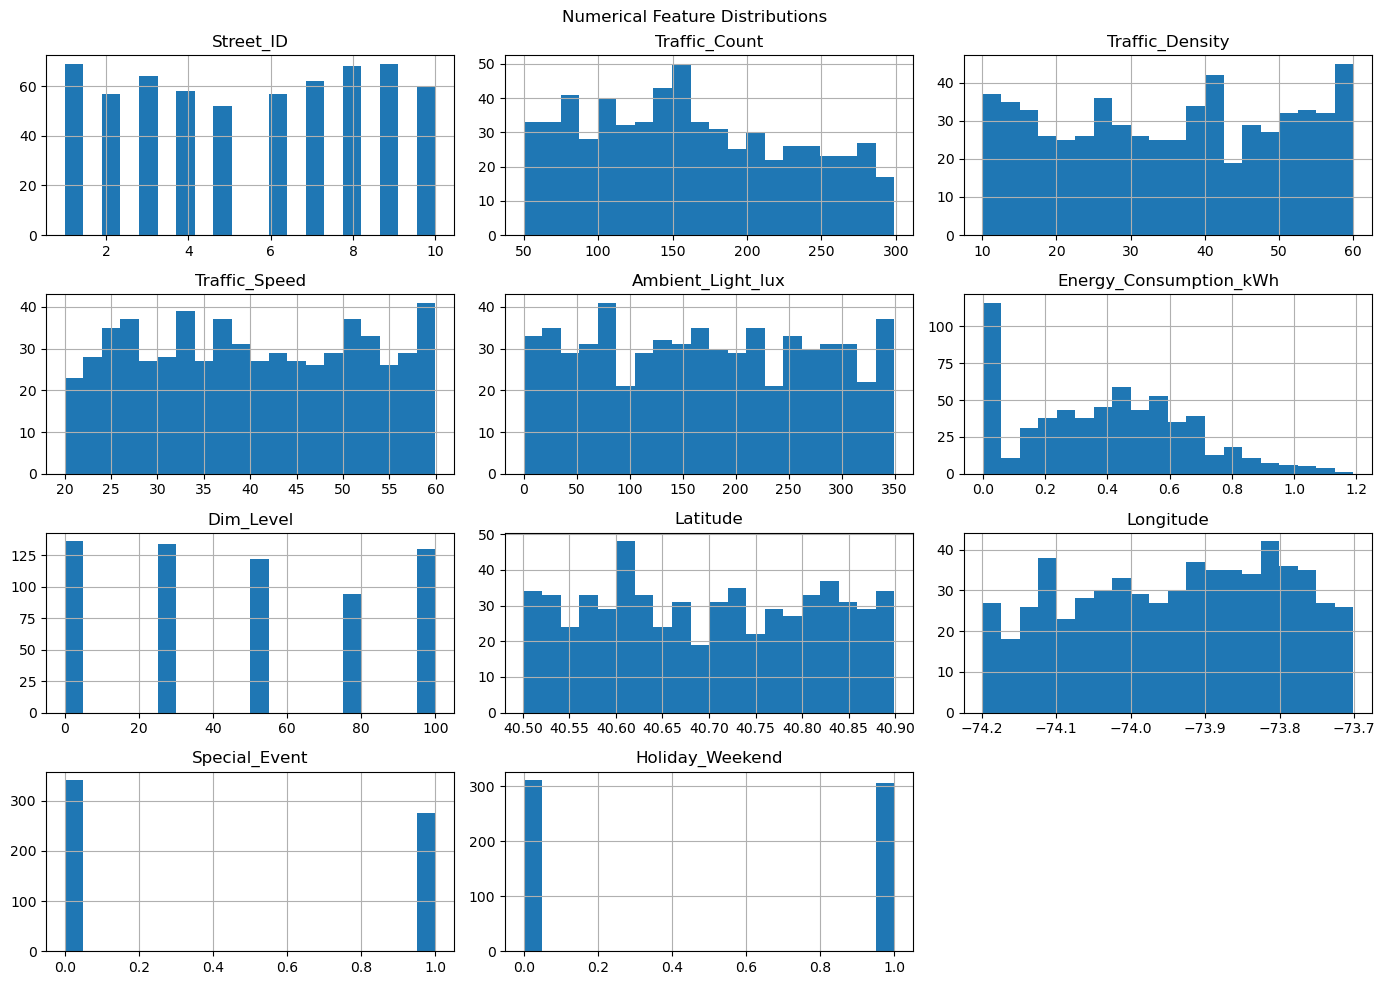

In [55]:
if len(numeric_cols) > 0:
    df[numeric_cols].hist(figsize=(14, 10), bins=20)
    plt.suptitle("Numerical Feature Distributions")
    plt.tight_layout()
    plt.show()

# 3.2 Correlation Heatmap

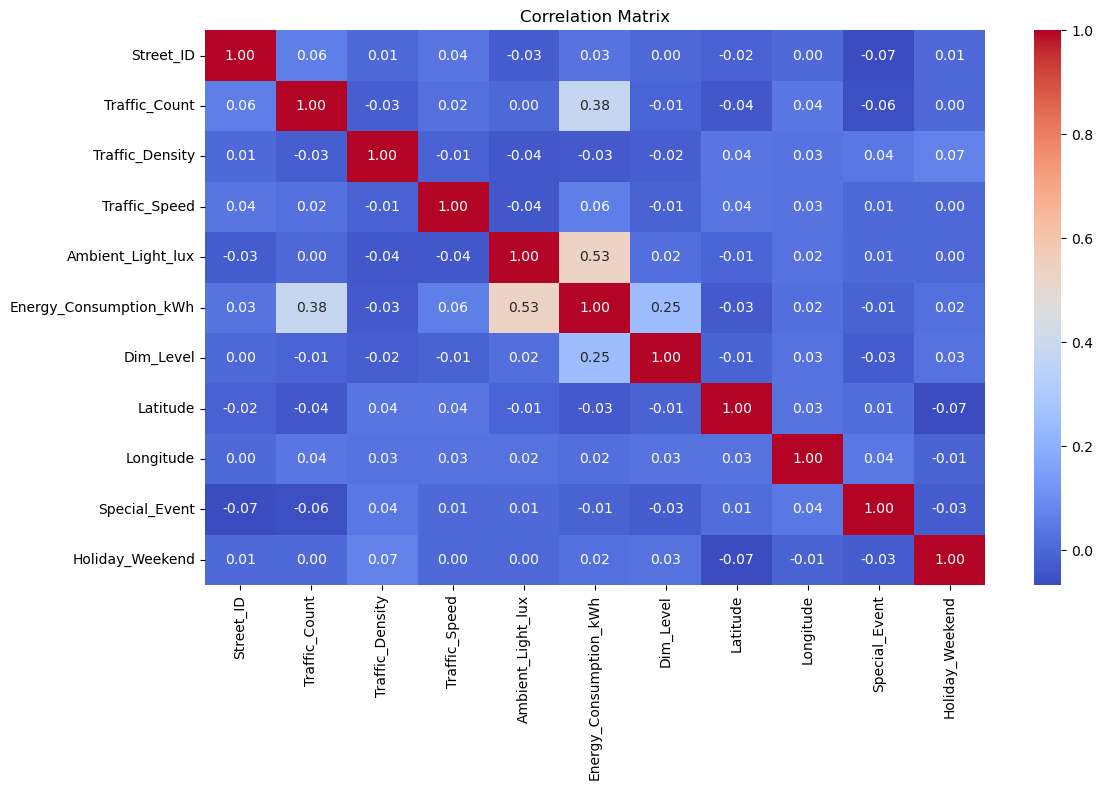

In [56]:
if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 8))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

# 3.3 Energy Consumption distribution

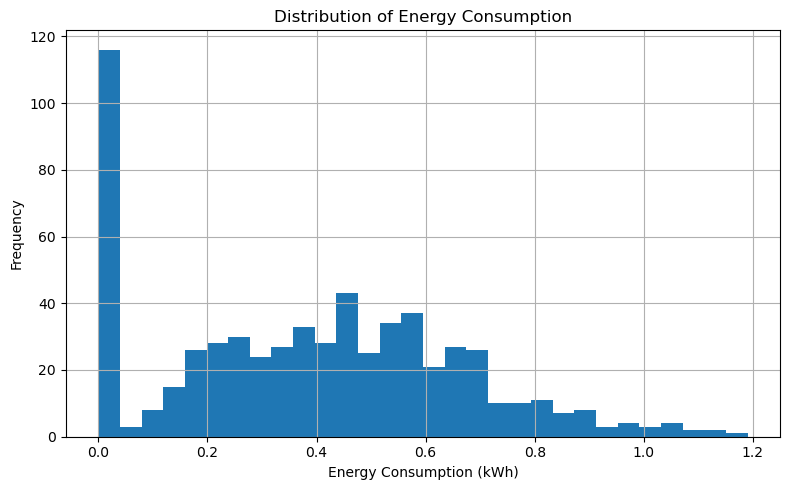

In [57]:
if "Energy_Consumption_kWh" in df.columns:
    plt.figure(figsize=(8, 5))
    df["Energy_Consumption_kWh"].hist(bins=30)
    plt.title("Distribution of Energy Consumption")
    plt.xlabel("Energy Consumption (kWh)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# 3.4 Power State distribution

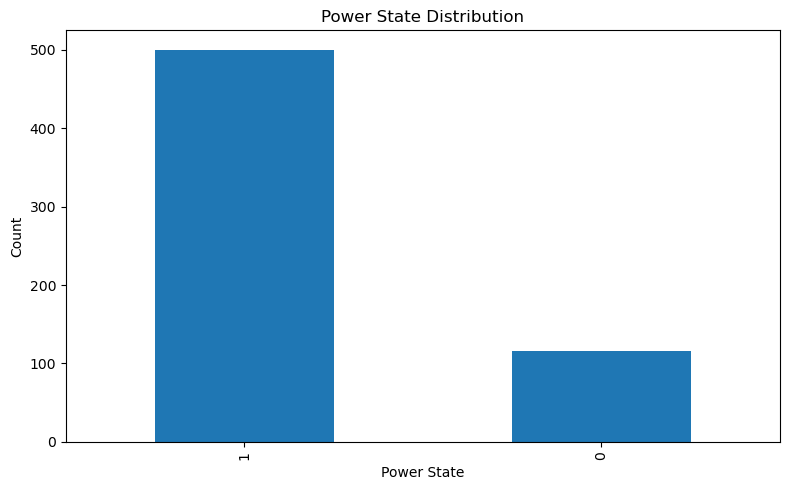

In [58]:
if "Power_State" in df.columns:
    plt.figure(figsize=(8, 5))
    df["Power_State"].value_counts().plot(kind="bar")
    plt.title("Power State Distribution")
    plt.xlabel("Power State")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# 3.5 Energy vs Hour

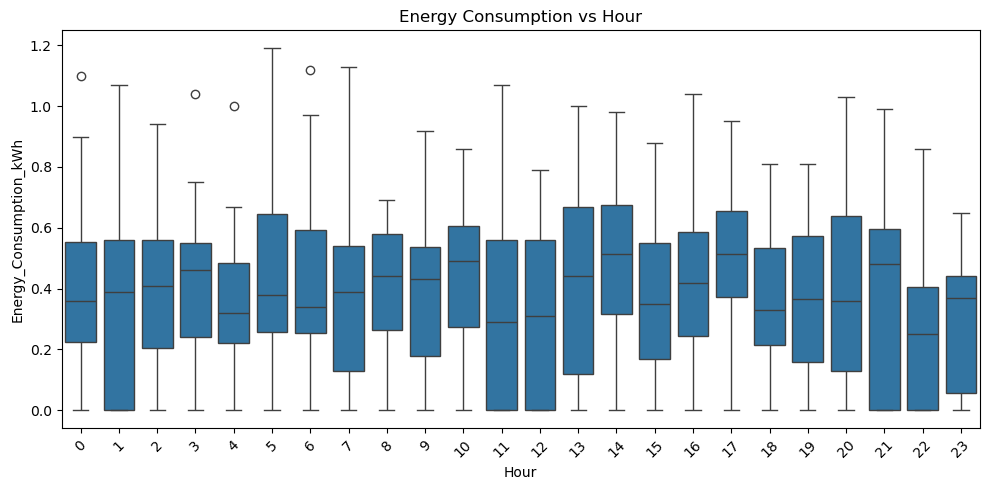

In [59]:
if "Hour" in df.columns and "Energy_Consumption_kWh" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x="Hour", y="Energy_Consumption_kWh", data=df)
    plt.title("Energy Consumption vs Hour")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3.6 Traffic Density vs Energy

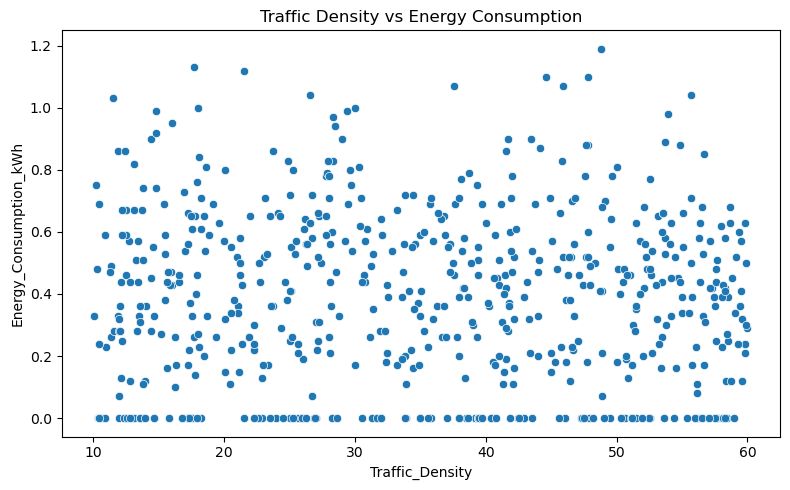

In [60]:
if "Traffic_Density" in df.columns and "Energy_Consumption_kWh" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x="Traffic_Density", y="Energy_Consumption_kWh", data=df)
    plt.title("Traffic Density vs Energy Consumption")
    plt.tight_layout()
    plt.show()

# 3.7 Weather vs Energy

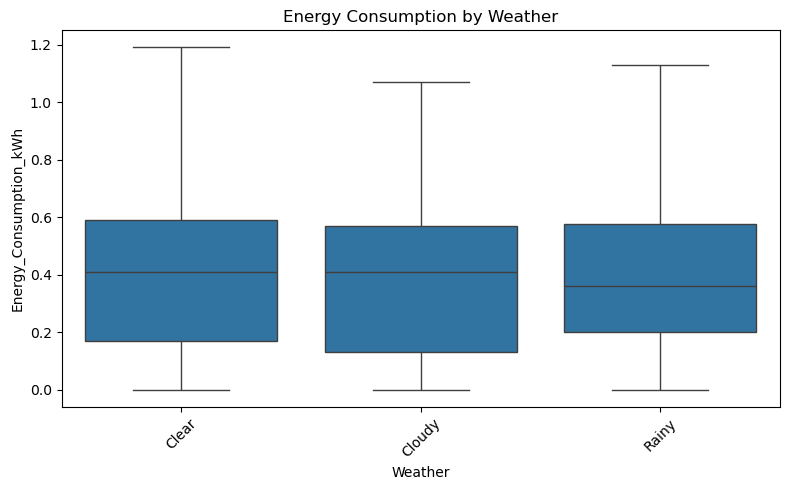

In [61]:
if "Weather" in df.columns and "Energy_Consumption_kWh" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x="Weather", y="Energy_Consumption_kWh", data=df)
    plt.title("Energy Consumption by Weather")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3.8 Day/Night vs Energy

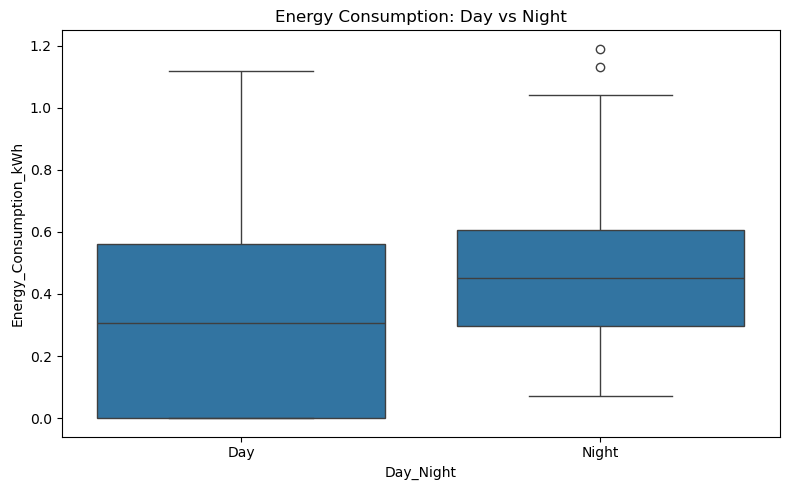

In [62]:
if "Day_Night" in df.columns and "Energy_Consumption_kWh" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x="Day_Night", y="Energy_Consumption_kWh", data=df)
    plt.title("Energy Consumption: Day vs Night")
    plt.tight_layout()
    plt.show()

# 4. FEATURE ENGINEERING

In [63]:
categorical_features = [col for col in ["Day_Night", "Weather"] if col in df.columns]

numeric_features = [
    col for col in df.columns
    if col not in categorical_features + ["Energy_Consumption_kWh", "Power_State", "Cluster"]
]

print("\n=== CATEGORICAL FEATURES ===")
print(categorical_features)

print("\n=== NUMERICAL FEATURES ===")
print(numeric_features)

# Shared preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


=== CATEGORICAL FEATURES ===
['Day_Night', 'Weather']

=== NUMERICAL FEATURES ===
['Street_ID', 'Traffic_Count', 'Traffic_Density', 'Traffic_Speed', 'Ambient_Light_lux', 'Dim_Level', 'Latitude', 'Longitude', 'Special_Event', 'Holiday_Weekend', 'Hour', 'Day', 'Month']


# 5. REGRESSION MODEL
# Target: Energy Consumption


REGRESSION: Energy Consumption
MAE  : 0.1085
RMSE : 0.1615
R²   : 0.6237


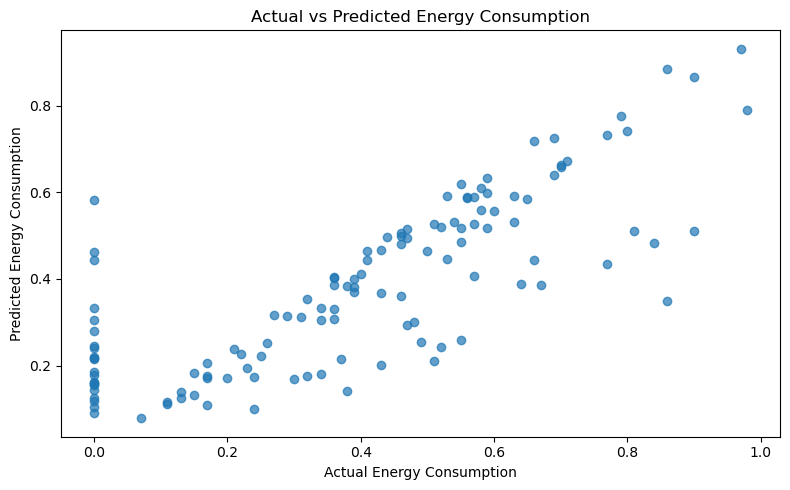

In [70]:
if "Energy_Consumption_kWh" in df.columns and "Power_State" in df.columns:
    print("\n=========================")
    print("REGRESSION: Energy Consumption")
    print("=========================")

    X_reg = df.drop(columns=["Energy_Consumption_kWh", "Power_State"], errors="ignore")
    y_reg = df["Energy_Consumption_kWh"]

    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42
    )

    regression_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, random_state=42))
    ])

    regression_model.fit(X_train_reg, y_train_reg)
    y_pred_reg = regression_model.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2 = r2_score(y_test_reg, y_pred_reg)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    # Actual vs Predicted plot 
    plt.figure(figsize=(8, 5)) 
    plt.scatter(y_test_reg, y_pred_reg, alpha=0.7) 
    plt.xlabel("Actual Energy Consumption") 
    plt.ylabel("Predicted Energy Consumption") 
    plt.title("Actual vs Predicted Energy Consumption") 
    plt.tight_layout() 
    plt.show()

# 6. CLASSIFICATION MODEL
# Target: Power State

In [65]:
if "Power_State" in df.columns and "Energy_Consumption_kWh" in df.columns:
    print("\n=========================")
    print("CLASSIFICATION: Power State")
    print("=========================")

    X_clf = df.drop(columns=["Power_State", "Energy_Consumption_kWh"], errors="ignore")
    y_clf = df["Power_State"]

    X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
        X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
    )

    classification_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ])

    classification_model.fit(X_train_clf, y_train_clf)
    y_pred_clf = classification_model.predict(X_test_clf)

    acc = accuracy_score(y_test_clf, y_pred_clf)

    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_clf, y_pred_clf))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_clf, y_pred_clf))


CLASSIFICATION: Power State
Accuracy: 0.8306

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.26      0.36        23
           1       0.85      0.96      0.90       101

    accuracy                           0.83       124
   macro avg       0.73      0.61      0.63       124
weighted avg       0.80      0.83      0.80       124

Confusion Matrix:
[[ 6 17]
 [ 4 97]]


# 7. CLUSTERING MODEL
# Unsupervised: Group similar lighting conditions


CLUSTERING: Streetlight Behaviour Segments

=== CLUSTER FEATURES ===
['Traffic_Count', 'Traffic_Density', 'Traffic_Speed', 'Ambient_Light_lux', 'Dim_Level', 'Hour', 'Month', 'Special_Event', 'Holiday_Weekend', 'Energy_Consumption_kWh']

=== SILHOUETTE SCORES FOR DIFFERENT K ===
k = 2, Silhouette Score = 0.1274
k = 3, Silhouette Score = 0.1129
k = 4, Silhouette Score = 0.1081
k = 5, Silhouette Score = 0.0989
k = 6, Silhouette Score = 0.1032

Best k: 2
Best Silhouette Score: 0.1274

Cluster Counts:
Cluster
0    259
1    357
Name: count, dtype: int64

Cluster-wise Mean Values:
         Traffic_Count  Traffic_Density  Traffic_Speed  Ambient_Light_lux  \
Cluster                                                                     
0           189.938224        34.398538      40.902750         248.657277   
1           142.588235        36.158392      39.865272         117.495566   

         Dim_Level       Hour  Month  Special_Event  Holiday_Weekend  \
Cluster                              

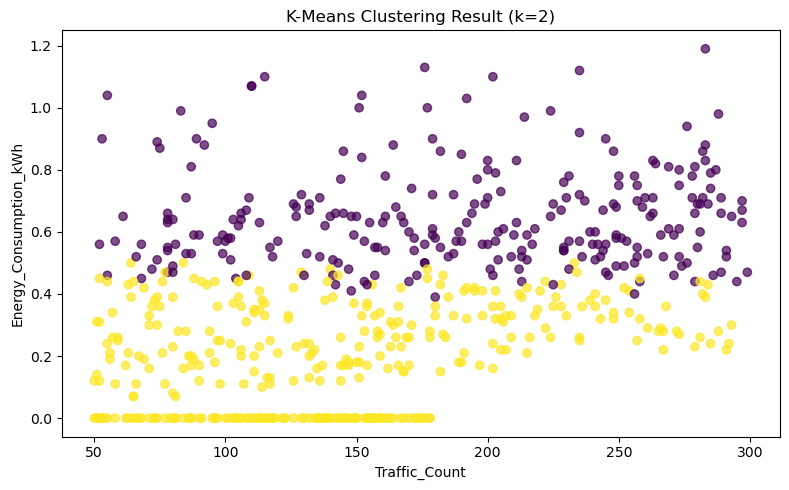

In [66]:
print("\n=========================")
print("CLUSTERING: Streetlight Behaviour Segments")
print("=========================")

# Better feature selection for clustering
cluster_features = [
    col for col in [
        "Traffic_Count",
        "Traffic_Density",
        "Traffic_Speed",
        "Ambient_Light_lux",
        "Dim_Level",
        "Hour",
        "Month",
        "Special_Event",
        "Holiday_Weekend",
        "Energy_Consumption_kWh"
    ] if col in df.columns
]

print("\n=== CLUSTER FEATURES ===")
print(cluster_features)

if len(cluster_features) >= 2:
    X_cluster = df[cluster_features].copy()

    # Preprocessing
    cluster_preprocessor = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    X_cluster_processed = cluster_preprocessor.fit_transform(X_cluster)

    # Try multiple k values and select the best one
    best_k = None
    best_score = -1
    best_labels = None
    best_model = None

    print("\n=== SILHOUETTE SCORES FOR DIFFERENT K ===")
    for k in range(2, 7):   # test k = 2 to 6
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_cluster_processed)
        score = silhouette_score(X_cluster_processed, labels)
        print(f"k = {k}, Silhouette Score = {score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
            best_model = kmeans

    # Save best clustering result
    df["Cluster"] = best_labels

    print(f"\nBest k: {best_k}")
    print(f"Best Silhouette Score: {best_score:.4f}")

    print("\nCluster Counts:")
    print(df["Cluster"].value_counts().sort_index())

    print("\nCluster-wise Mean Values:")
    print(df.groupby("Cluster")[cluster_features].mean())

    # Better 2D visualization
    x_axis = "Traffic_Count" if "Traffic_Count" in cluster_features else cluster_features[0]
    y_axis = "Energy_Consumption_kWh" if "Energy_Consumption_kWh" in cluster_features else cluster_features[1]

    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(df[x_axis], df[y_axis], c=df["Cluster"], alpha=0.7)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.title(f"K-Means Clustering Result (k={best_k})")
    plt.tight_layout()
    plt.show()

else:
    print("Not enough numeric features available for clustering.")

# 8. SAVE CLEANED DATA

In [67]:
output_file = "cleaned_intelligent_streetlight_dataset.csv"
df.to_csv(output_file, index=False)
print(f"\nCleaned dataset saved as: {output_file}")

print("\n=== DONE ===")


Cleaned dataset saved as: cleaned_intelligent_streetlight_dataset.csv

=== DONE ===
